# QC Analysis Notebook

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
QC_DIR = PROJECT_ROOT / "metadata" / "signal_quality"
REPORT_DIR = PROJECT_ROOT / "reports" / "signal_quality"

REPORT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
chunks = pd.read_csv(
    QC_DIR / "chbmit_qc_chunks.csv"
)

channels = pd.read_csv(
    QC_DIR / "chbmit_qc_channels.csv"
)

recordings_qc = pd.read_csv(
    QC_DIR / "chbmit_qc_recordings.csv"
)

failures = pd.read_csv(
    QC_DIR / "chbmit_qc_failures.csv"
)

print("Chunk-channel rows:", len(chunks))
print("Channel rows:", len(channels))
print("Recording rows:", len(recordings_qc))
print("Failures:", len(failures))

Chunk-channel rows: 1379528
Channel rows: 17175
Recording rows: 657
Failures: 0


# Comparison of ictal and non-ictal
This table is methodologically very important. If ictal chunks naturally have higher amplitude or line length, artifact thresholds should not be applied regardless of annotation.

In [3]:
chunks.groupby("annotation_label")[
    [
        "rms_uv",
        "peak_to_peak_uv",
        "line_length_uv",
        "flatline_sample_fraction",
        "line_noise_ratio",
        "high_frequency_ratio",
        "spectral_entropy",
    ]
].median().T

annotation_label,boundary,ictal,non_ictal
rms_uv,47.789924,55.959177,32.816369
peak_to_peak_uv,558.339438,651.233211,398.534799
line_length_uv,98499.633700,143595.604396,79149.401709
flatline_sample_fraction,0.000000,0.000000,0.000000
line_noise_ratio,0.250959,0.260614,0.461782
high_frequency_ratio,0.007892,0.010604,0.013644
spectral_entropy,0.610157,0.645279,0.621122


# RMS distribution of channels

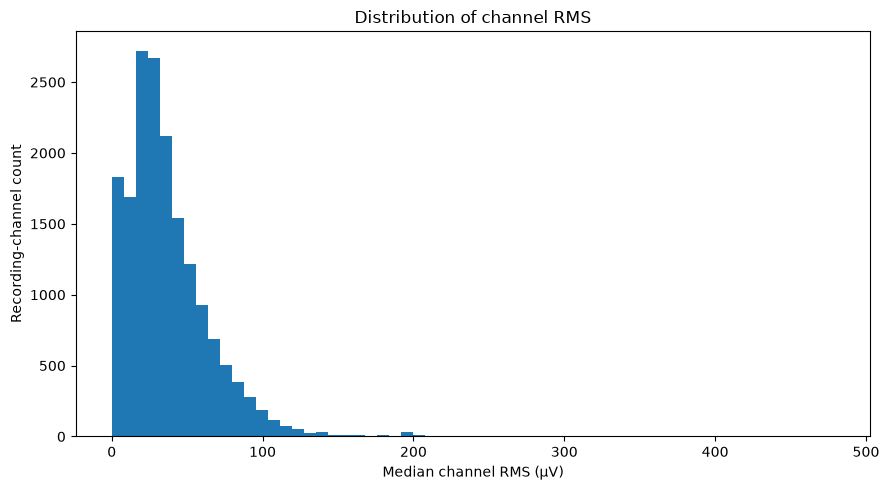

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

valid = channels["median_rms_uv"].dropna()

ax.hist(valid, bins=60)
ax.set_xlabel("Median channel RMS (µV)")
ax.set_ylabel("Recording-channel count")
ax.set_title("Distribution of channel RMS")

fig.tight_layout()
fig.savefig(
    REPORT_DIR / "channel_rms_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Flatline

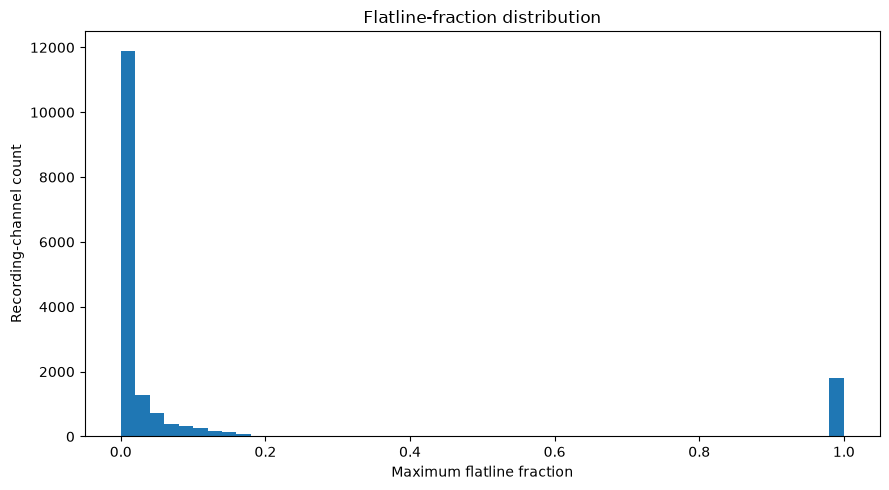

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    channels["maximum_flatline_fraction"].dropna(),
    bins=50,
)

ax.set_xlabel("Maximum flatline fraction")
ax.set_ylabel("Recording-channel count")
ax.set_title("Flatline-fraction distribution")

fig.tight_layout()
fig.savefig(
    REPORT_DIR / "flatline_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Line noise

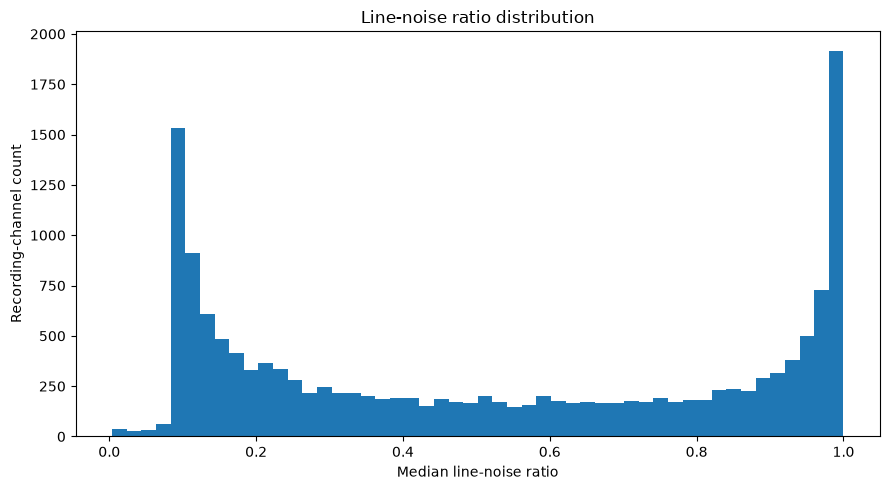

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    channels["median_line_noise_ratio"].dropna(),
    bins=50,
)

ax.set_xlabel("Median line-noise ratio")
ax.set_ylabel("Recording-channel count")
ax.set_title("Line-noise ratio distribution")

fig.tight_layout()
fig.savefig(
    REPORT_DIR / "line_noise_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

 Files that need to be reviewed

In [7]:
review_recordings = recordings_qc.loc[
    recordings_qc["recording_needs_review"]
].sort_values(
    [
        "reviewed_channel_fraction",
        "maximum_flatline_fraction",
        "maximum_line_noise_ratio",
    ],
    ascending=False,
)

review_recordings.head(30)

,case_id,recording_id,channel_count,reviewed_channel_count,median_channel_rms_uv,maximum_channel_rms_uv,maximum_flatline_fraction,maximum_line_noise_ratio,maximum_high_frequency_ratio,reviewed_channel_fraction,recording_needs_review
351,chb13,chb13_15,22,22,34.878303,401.660475,1.0,0.999983,0.995699,1.0,True
511,chb18,chb18_35,28,28,14.249188,158.549250,1.0,0.999978,0.955056,1.0,True
352,chb13,chb13_16,22,22,37.384805,579.232473,1.0,0.999977,0.997464,1.0,True
350,chb13,chb13_14,22,22,31.405026,251.353853,1.0,0.999961,0.990979,1.0,True
347,chb13,chb13_11,22,22,33.671188,254.122042,1.0,0.999952,0.974622,1.0,True
457,chb17,chb17a_04,28,28,22.150729,144.795788,1.0,0.999951,0.949502,1.0,True
348,chb13,chb13_12,22,22,34.008554,201.433039,1.0,0.999948,0.974886,1.0,True
349,chb13,chb13_13,22,22,30.100469,262.761051,1.0,0.999938,0.977211,1.0,True
541,chb19,chb19_29,28,28,28.269749,294.523944,1.0,0.999935,0.589988,1.0,True
367,chb13,chb13_58,28,28,35.192537,290.843374,1.0,0.999924,0.951343,1.0,True


# Checking that the problem is not ictal-only
A channel should not be automatically declared bad just because of its behavior during a seizure.

In [8]:
review_by_annotation = (
    chunks.loc[chunks["needs_review"]]
    .groupby(
        [
            "recording_id",
            "channel_name",
            "annotation_label",
        ]
    )
    .size()
    .rename("review_chunk_count")
    .reset_index()
)

review_by_annotation.head()

,recording_id,channel_name,annotation_label,review_chunk_count
0,chb01_01,C3-P3,non_ictal,60
1,chb01_01,C4-P4,non_ictal,60
2,chb01_01,CZ-PZ,non_ictal,60
3,chb01_01,F4-C4,non_ictal,57
4,chb01_01,F7-T7,non_ictal,60


# Phase 4 
Manual MNE review

In [10]:
import mne
import pandas as pd

selected = chunks.loc[
    chunks["needs_review"]
].sort_values(
    "flag_count",
    ascending=False,
).iloc[0]

edf_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "chbmit"
    / selected["edf_relative_path"]
)

raw = mne.io.read_raw_edf(
    edf_path,
    preload=False,
    verbose="ERROR",
)

raw.plot(
    start=float(selected["chunk_start_seconds"]),
    duration=min(
        60,
        float(selected["chunk_duration_seconds"]),
    ),
    n_channels=min(24, len(raw.ch_names)),
    scalings="auto",
)

Using qt as 2D backend.


Channels marked as bad:
none


# For manual PSD:

Plotting power spectral density (dB=True).


C:\Users\Sara\AppData\Local\Temp\ipykernel_23240\840404976.py:12: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  spectrum.plot(
C:\Users\Sara\anaconda3\envs\epilepsy-eeg\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


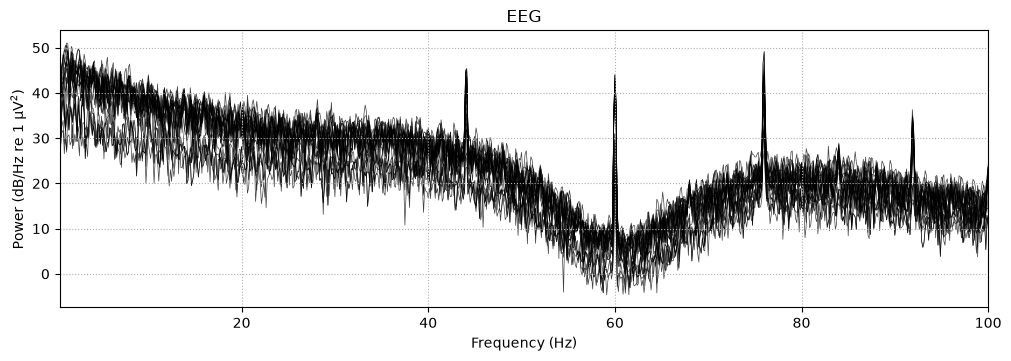

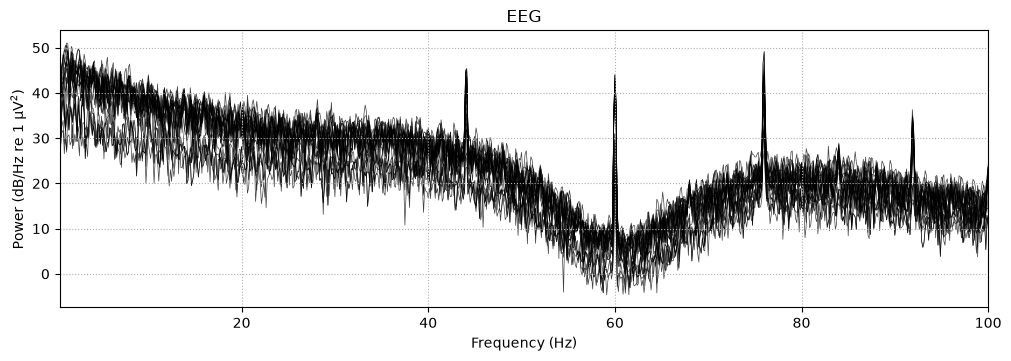

In [11]:
spectrum = raw.compute_psd(
    method="welch",
    fmin=0.5,
    fmax=100,
    tmin=float(selected["chunk_start_seconds"]),
    tmax=float(selected["chunk_end_seconds"]),
    picks="data",
    remove_dc=True,
    verbose="ERROR",
)

spectrum.plot(
    average=False,
    amplitude=False,
)